# Artificial Neural Networks

This notebook shows the solutions to creating a neural network to predict digits from 8x8 images

In [1]:
import numpy as np
import numpy.typing as npt
from sklearn import datasets
import typing
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# sklearn datasets

We will take advantage of the sklearn [digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).

Each datapoint is a 8x8 image of a digit.

| Metric | Value |
|:---|:---|
| Classes | 10 |
| Samples per class | ca. 180 |
| Samples total | 1797 |
| Dimensionality | 64 |



In [2]:
digits = datasets.load_digits()
first_digit = digits.data[0] # type: ignore
first_digit

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

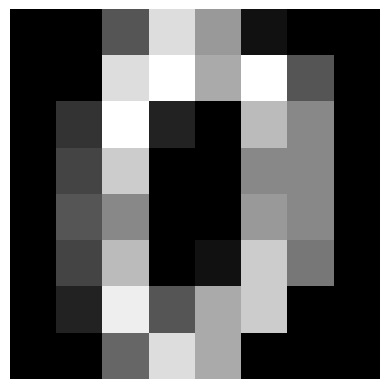

In [3]:
plt.imshow(first_digit.reshape(8,8), cmap='gray')
plt.axis('off')
plt.show()

In [4]:
targets = digits.target[0] # type: ignore
targets

np.int64(0)

# Setting up the ANN

For any real work, it is almost always a better idea to use a framework such as PyTorch to construct ANNs, and we will do this in subsequent homeworks. For this assignment, we will code up a simple ANN in plain Python to help studens gain intuition.

#  Activation and Loss Functions

In [5]:
def sigmoid(x: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """Computes the sigmoid of x (our activation function)."""
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_prime(x: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """Computes the derivative of the sigmoid function."""
    return sigmoid(x)*(1.0 - sigmoid(x))


def mse(y_true: npt.NDArray[np.float64], y_pred: npt.NDArray[np.float64]) -> np.float64:
    """Computes the Mean Squared Error (a single scalar)."""
    return (0.5*(y_true - y_pred)**2).mean()

def mse_prime(y_true: npt.NDArray[np.float64], y_pred: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """Computes the derivative of the MSE with respect to y_pred."""
    return y_pred - y_true

# Activation Layer


In [6]:
class ActivationLayer:
    input: typing.Optional[npt.NDArray[np.float64]]

    def forward(self, input_data: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        self.input = input_data
        return sigmoid(input_data)


    def backward(self, output_error: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        return sigmoid_prime(self.input) * output_error # type: ignore (We know self.input will be npt.NDArray[np.float64]
    
    def step(self, eta: float) -> None:
        """
        Activation layers have no trainable parameters, 
        so the step method does nothing.
        """
        return

# FFN

In [7]:

class FullyConnectedLayer:

    weights: npt.NDArray[np.float64]
    bias: npt.NDArray[np.float64]
    delta_w: npt.NDArray[np.float64]
    delta_b: npt.NDArray[np.float64]
    passes: int
    input: typing.Optional[npt.NDArray[np.float64]]

    def __init__(self, input_size: int, output_size: int):
        #  for accumulating error over a minibatch
        self.delta_w = np.zeros((input_size, output_size))
        self.delta_b = np.zeros((1,output_size))
        self.passes = 0

        #  initialize the weights and biases w/small random values
        self.weights = np.random.rand(input_size, output_size) - 0.5
        self.bias = np.random.rand(1, output_size) - 0.5

    def forward(self, input_data: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        self.input = input_data
        return np.dot(self.input, self.weights) + self.bias

    def backward(self, output_error: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        input_error = np.dot(output_error, self.weights.T)
        weights_error = np.dot(self.input.T, output_error) # type: ignore (We know self.input will be npt.NDArray[np.float64]

        #  accumulate the error over the minibatch
        self.delta_w += weights_error
        self.delta_b += output_error
        self.passes += 1
        return input_error

    def step(self, eta: float) -> None:
        #  update the weights and biases by the mean error
        #  over the minibatch
        self.weights -= eta * self.delta_w / self.passes
        self.bias -= eta * self.delta_b / self.passes

        #  reset for the next minibatch
        self.delta_w = np.zeros(self.weights.shape)
        self.delta_b = np.zeros(self.bias.shape)
        self.passes = 0

# Network

In [8]:
Layer = typing.Union[FullyConnectedLayer, ActivationLayer]
ArrayOfFloats = npt.NDArray[np.float64]

class Network:
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.layers = []

    def add(self, layer: Layer) -> None:
        self.layers.append(layer)

    def predict(self, input_data: ArrayOfFloats) -> typing.List[ArrayOfFloats]:
        result = []
        for i in range(input_data.shape[0]):
            output = input_data[i]
            for layer in self.layers:
                output = layer.forward(output)
            result.append(output)
        return result

    def fit(self, 
            x_train: ArrayOfFloats, 
            y_train: npt.NDArray[np.float64], 
            minibatches: int, 
            learning_rate: float, 
            batch_size: int=64) -> None:
        for i in range(minibatches):
            err = 0

            # select a random minibatch
            idx = np.argsort(np.random.random(x_train.shape[0]))[:batch_size]
            x_batch = x_train[idx]
            y_batch = y_train[idx]

            for j in range(batch_size):
                # forward propagation
                output = x_batch[j]
                for layer in self.layers:
                    output = layer.forward(output)

                # accumulate loss
                err += mse(y_batch[j], output)

                # backward propagation
                error = mse_prime(y_batch[j], output)
                for layer in reversed(self.layers):
                    error = layer.backward(error)
            
            #  update weights and biases
            for layer in self.layers:
                layer.step(learning_rate)

            # report mean loss over minibatch
            if (self.verbose) and ((i%10) == 0):
                err /= batch_size
                print('minibatch %5d/%d   error=%0.9f' % (i, minibatches, err))


# x

In [9]:
# Before splitting, reshape X to be (1797, 1, 64) 
# instead of (1797, 64)
#X = digits.data.reshape(digits.data.shape[0], 1, 64) # type: ignore
X = digits.data.reshape(-1, 1, 64)

y = digits.target # type: ignore

print(f"Shape of X: {X.shape}")
# 3. Create the datasets
# test_size=0.2 means 20% goes to testing, 80% to training

# One-Hot Encoded (e.g., 3 becomes [0,0,0,1,0,0,0,0,0,0])
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y_reshaped = enc.fit_transform(y.reshape(-1, 1)).toarray()

# Now split with the reshaped data
X_train, X_test, y_train, y_test = train_test_split(X, y_reshaped, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Shape of X: (1797, 1, 64)
Training set size: 1437
Testing set size: 360


# Set up the network

In [10]:
network = Network()
network.add(FullyConnectedLayer(64, 128))
network.add(ActivationLayer())
network.add(FullyConnectedLayer(128, 64))
network.add(ActivationLayer())
network.add(FullyConnectedLayer(64, 10))
network.add(ActivationLayer())

# Train the network

In [ ]:
network.fit(X_train, y_train, minibatches=40000, learning_rate=0.5)

# Assess the performance

In [12]:
out = network.predict(X_test)
cm = np.zeros((10,10), dtype="uint32")
for i in range(len(y_test)):
    # Convert the One-Hot ground truth back to an integer (0-9)
    true_label = np.argmax(y_test[i])
    # Convert the network output (probabilities) to an integer (0-9)
    # Note: out[i] is (1, 10), so argmax works fine
    predicted_label = np.argmax(out[i])
    cm[true_label, predicted_label] += 1
print()
print(np.array2string(cm))
print()
print("Accuracy = %0.7f" % (np.diag(cm).sum() / cm.sum()))


[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 1  0  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  0  0  0  1  0  0 28  0]
 [ 0  0  0  0  0  0  0  1  0 39]]

Accuracy = 0.9750000


# Dimensionality checks

In [13]:
print(f"Shape of X_test {X_test.shape}, shape of one item {X_test[0].shape}")

Shape of X_test (360, 1, 64), shape of one item (1, 64)


In [14]:
print(f"Shape of digits {digits.data.shape}")
print(f"Shape of an element: '{digits.data[0].shape}'")

Shape of digits (1797, 64)
Shape of an element: '(64,)'


In [15]:
xt = X_test[0]
out = network.predict(xt)
print(out)
print(y_test[0])

[array([[6.68476122e-04, 2.95670858e-03, 1.30580251e-04, 2.58384179e-05,
        1.88285870e-03, 2.37070155e-03, 9.95841230e-01, 2.64367427e-04,
        1.51421317e-03, 1.42586125e-05]])]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
